<a href="https://colab.research.google.com/github/daminishrawan/Gen-AI-tasks/blob/master/Assignment_2_NN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Fixed Neural Network Architecture


In [51]:
import torch
import torch.nn as nn

# Define the Fixed Neural Network class
class FixedNeuralNetwork(nn.Module):
  def __init__(self):
    super(FixedNeuralNetwork, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(1, 64), # Input layer -> Hidden Layer 1
        nn.Tanh(), # Hidden layer activation
        nn.Linear(64, 64), # Hidden Layer 1 -> Hidden Layer 2
        nn.Tanh(), # Hidden layer activation
        nn.Linear(64, 1) # Hidden Layer 2 -> Output layer (Linear output)
    )

  def forward(self, x):
    return self.net(x)

# Instantiate the model (optional, as per original comment, but keeping for completeness)
model = FixedNeuralNetwork()

# ==========================================
# Print the Network Architecture Output
# ==========================================

print("--- Model Architecture ---")
print(model)

# =================================================
# Calculate &amp; Print Trainable Parameter Count
# =================================================
print("\n====================================================================================")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params}")

# ==========================================
# Test Forward Pass Output (Dummy Input)
# ==========================================
print("\n====================================================================================")
# Sample 3 input points: x = -1.0, 0.0, 1.0
sample_x = torch.tensor([[-1.0], [0.0], [1.0]], dtype=torch.float32)

# Pass through model
sample_y_pred = model(sample_x)

print("Sample Inputs shape :", sample_x.shape)
print("Sample Outputs shape:", sample_y_pred.shape)
print("Sample Output values:\n", sample_y_pred)


--- Model Architecture ---
FixedNeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total Trainable Parameters: 4353

Sample Inputs shape : torch.Size([3, 1])
Sample Outputs shape: torch.Size([3, 1])
Sample Output values:
 tensor([[ 0.2138],
        [ 0.0530],
        [-0.1054]], grad_fn=<AddmmBackward0>)


# Parts B–F: Data generation, explicit training loop, 4 target function plots, training loss curves, and summary Table 2

--- Mandatory Assignment Metadata ---
Python Version : ['3.13.15', '(main,', 'Aug', '6', '2026,', '11:06:22)', '[GCC', '13.3.0]']
PyTorch Version : 2.11.0+cpu
Random Seed : 42
Number of training samples: 100
Test Samples : 500
Learning Rate : 0.005
Epochs : 2000
Optimizer : Adam
Loss Function : MSELoss
-------------------------------------



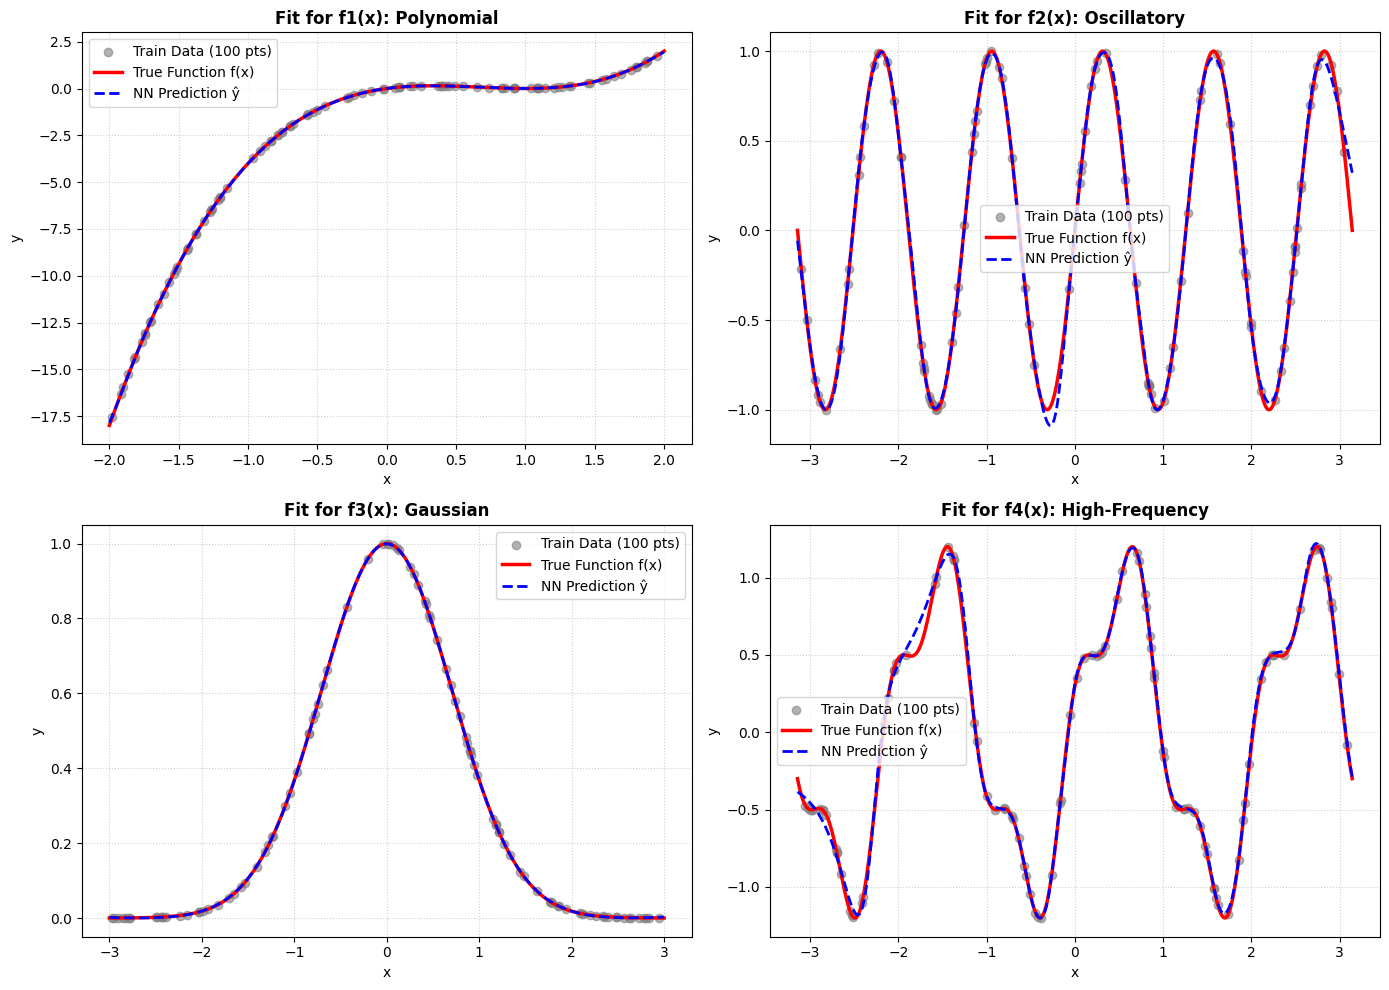

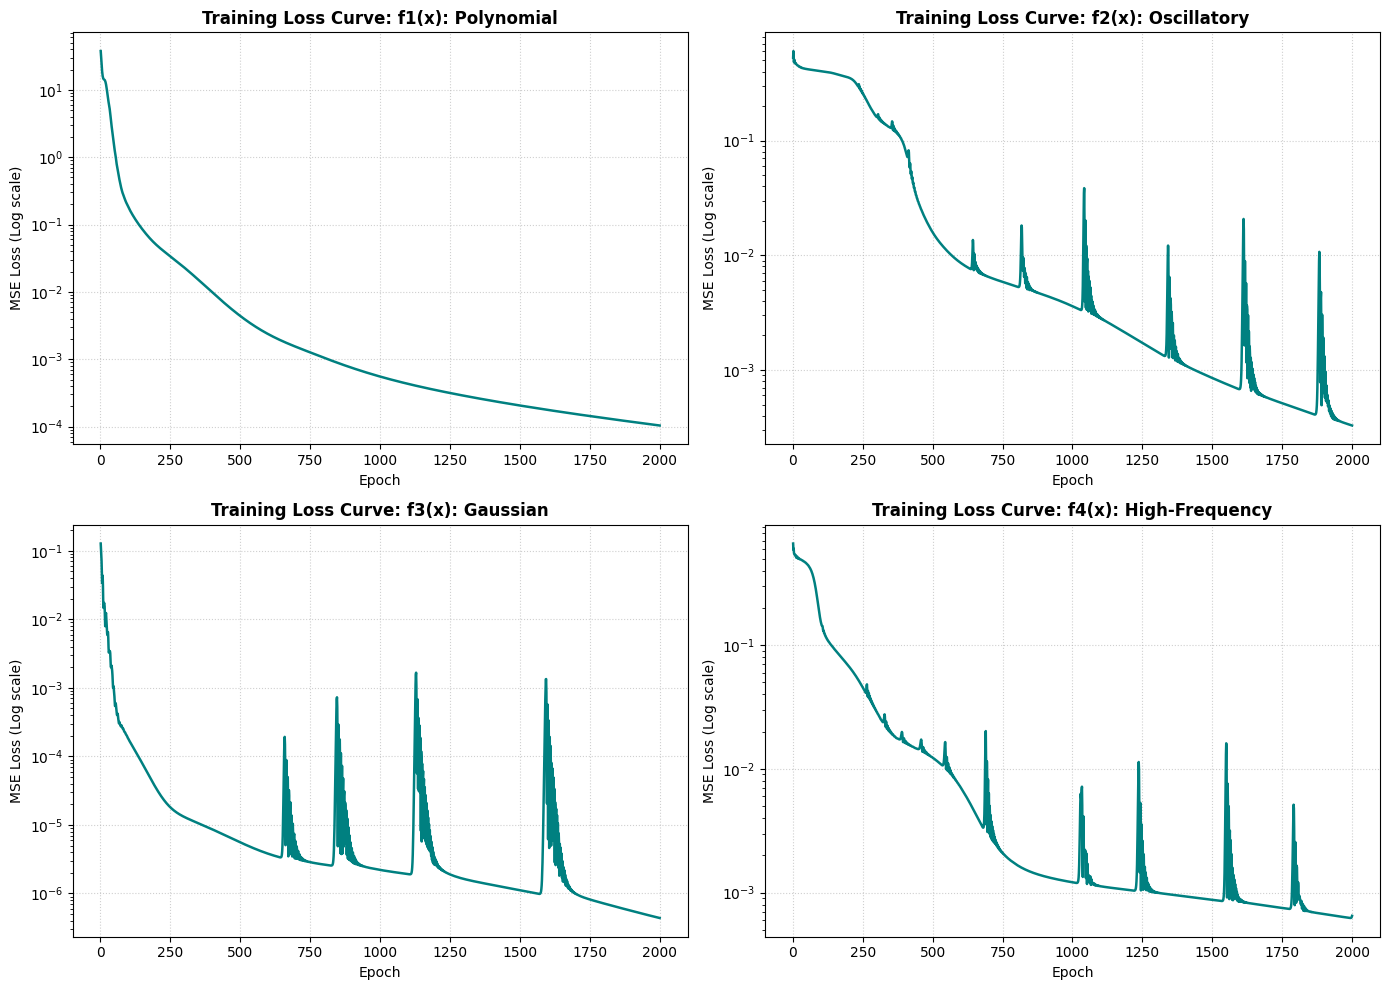


 Table 2: Performance of the Fixed Neural Network Architecture 
             Function       Architecture Final Train Loss Test MSE Test MAE  Epochs  Parameters
    f1(x): Polynomial 1 -> 64 -> 64 -> 1         0.000104 0.000156 0.005571    2000        4353
   f2(x): Oscillatory 1 -> 64 -> 64 -> 1         0.000328 0.001633 0.022616    2000        4353
      f3(x): Gaussian 1 -> 64 -> 64 -> 1         0.000000 0.000001 0.000614    2000        4353
f4(x): High-Frequency 1 -> 64 -> 64 -> 1         0.000648 0.001508 0.024375    2000        4353



In [52]:
import sys, torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Mandatory Metadata & Reproducibility
# ==========================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("--- Mandatory Assignment Metadata ---")
print(f"Python Version : {sys.version.split()}")
print(f"PyTorch Version : {torch.__version__}")
print(f"Random Seed : {SEED}")
print(f"Number of training samples: 100")
print(f"Test Samples : 500")
print(f"Learning Rate : 0.005")
print(f"Epochs : 2000")
print(f"Optimizer : Adam")
print(f"Loss Function : MSELoss")
print("-------------------------------------\n")

# ==========================================
# 2. Fixed Neural Network Class
# ==========================================
class FixedNeuralNetwork(nn.Module):
    def __init__(self):
        super(FixedNeuralNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1) # Linear output
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. Data Generation Helper
# ==========================================
def generate_dataset(func, x_min, x_max, n_train=100, n_test=500):
    # 1. Sample 100 random training points uniformly across the domain
    x_train_np = np.random.uniform(x_min, x_max, (n_train, 1)).astype(np.float32)
    y_train_np = func(x_train_np)

    # 2. Smooth grid of 500 test points for evaluation
    x_test_np = np.linspace(x_min, x_max, n_test).reshape(-1, 1).astype(np.float32)
    y_test_np = func(x_test_np)

    x_train = torch.from_numpy(x_train_np)
    y_train = torch.from_numpy(y_train_np)
    x_test = torch.from_numpy(x_test_np)
    y_test = torch.from_numpy(y_test_np)

    return x_train, y_train, x_test, y_test, x_train_np, y_train_np, x_test_np, y_test_np

# ==========================================
# 4. Target Function Definitions & Domains
# ==========================================
target_functions = {
    "f1(x): Polynomial": {
        "func": lambda x: x**3 - 2*x**2 + x,
        "domain": (-2.0, 2.0)
    },
    "f2(x): Oscillatory": {
        "func": lambda x: np.sin(5*x),
        "domain": (-np.pi, np.pi)
    },
    "f3(x): Gaussian": {
        "func": lambda x: np.exp(-x**2),
        "domain": (-3.0, 3.0)
    },
    "f4(x): High-Frequency": {
        "func": lambda x: np.sin(3*x) + 0.3*np.cos(9*x),
        "domain": (-np.pi, np.pi)
    }
}

# ==========================================
# 5. Training & Evaluation Pipeline
# ==========================================
summary_results = []
trained_models_data = {}

# Set up 2x2 Grid for Function Fits and 2x2 Grid for Loss Curves
fig_fits, axes_fits = plt.subplots(2, 2, figsize=(14, 10))
axes_fits = axes_fits.flatten()
fig_loss, axes_loss = plt.subplots(2, 2, figsize=(14, 10))
axes_loss = axes_loss.flatten()

for idx, (func_name, config) in enumerate(target_functions.items()):
    func = config["func"]
    x_min, x_max = config["domain"]

    # Generate independent train & test sets
    x_tr, y_tr, x_te, y_te, x_tr_np, y_tr_np, x_te_np, y_te_np = generate_dataset(func, x_min, x_max)

    # CRITICAL: Instantiate a FRESH model instance for each function from scratch
    model = FixedNeuralNetwork()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    epochs = 2000
    loss_history = []

    # Explicit Training Loop
    for epoch in range(epochs):
        model.train()
        # (a) Forward pass
        y_pred = model(x_tr)
        # (b) Loss calculation
        loss = criterion(y_pred, y_tr)
        # (c) Gradient reset
        optimizer.zero_grad()
        # (d) Backpropagation
        loss.backward()
        # (e) Parameter update
        optimizer.step()
        loss_history.append(loss.item())

    # Evaluation on Independent Test Set
    model.eval()
    with torch.no_grad():
        test_preds = model(x_te)
        test_mse = nn.MSELoss()(test_preds, y_te).item()
        test_mae = nn.L1Loss()(test_preds, y_te).item()

    params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    final_train_loss = loss_history[-1]

    # Record metrics for Summary Table
    summary_results.append({
        "Function": func_name,
        "Architecture": "1 -> 64 -> 64 -> 1",
        "Final Train Loss": f"{final_train_loss:.6f}",
        "Test MSE": f"{test_mse:.6f}",
        "Test MAE": f"{test_mae:.6f}",
        "Epochs": epochs,
        "Parameters": params_count
    })

    # Plot Function Approximations
    ax_fit = axes_fits[idx]
    ax_fit.scatter(x_tr_np, y_tr_np, color='gray', alpha=0.6, label='Train Data (100 pts)')
    ax_fit.plot(x_te_np, y_te_np, 'r-', linewidth=2.5, label='True Function f(x)')
    ax_fit.plot(x_te_np, test_preds.numpy(), 'b--', linewidth=2.0, label='NN Prediction ŷ')
    ax_fit.set_title(f"Fit for {func_name}", fontsize=12, fontweight='bold')
    ax_fit.set_xlabel("x")
    ax_fit.set_ylabel("y")
    ax_fit.legend()
    ax_fit.grid(True, linestyle=':', alpha=0.6)

    # Plot Training Loss Curves
    ax_l = axes_loss[idx]
    ax_l.plot(range(1, epochs + 1), loss_history, color='teal', linewidth=1.8)
    ax_l.set_title(f"Training Loss Curve: {func_name}", fontsize=12, fontweight='bold')
    ax_l.set_xlabel("Epoch")
    ax_l.set_ylabel("MSE Loss (Log scale)")
    ax_l.set_yscale('log')
    ax_l.grid(True, linestyle=':', alpha=0.6)

fig_fits.tight_layout()
fig_loss.tight_layout()
plt.show()

# ==========================================
# 6. Part F: Print Summary Table
# ==========================================
summary_df = pd.DataFrame(summary_results)
print("\n====================================================================================")
print(" Table 2: Performance of the Fixed Neural Network Architecture ")
print("====================================================================================")
print(summary_df.to_string(index=False))
print("====================================================================================\n")

# **Part G** — Ablation Study

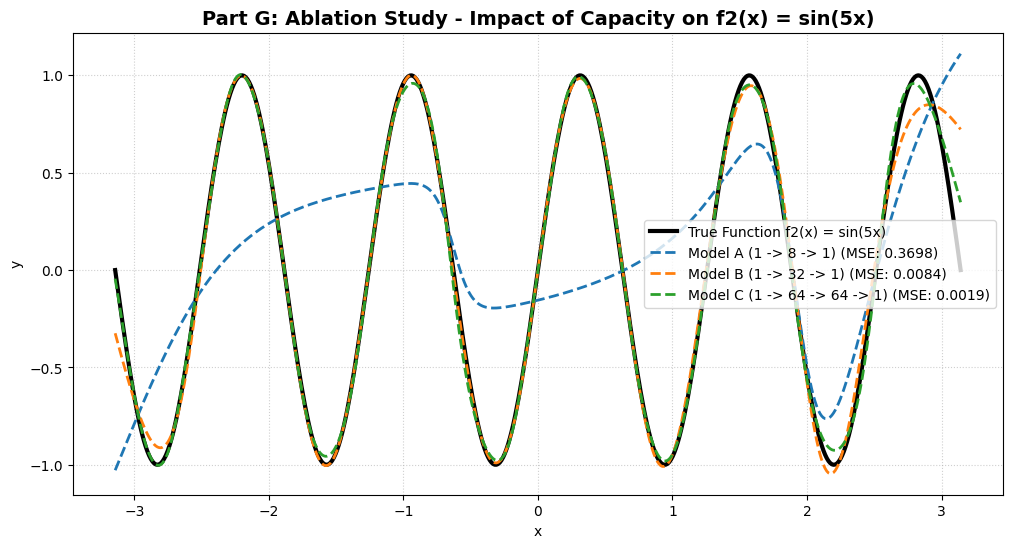


--- Part G: Ablation Study Comparison Table ---
          Model Architecture  Trainable Parameters Test MSE Test MAE
       Model A (1 -> 8 -> 1)                    25 0.369806 0.493703
      Model B (1 -> 32 -> 1)                    97 0.008393 0.041924
Model C (1 -> 64 -> 64 -> 1)                  4353 0.001886 0.024787


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Part G: Network Definitions
# ==========================================
class ModelA(nn.Module):
  def __init__(self):
    super(ModelA, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(1, 8),
        nn.Tanh(),
        nn.Linear(8, 1)
    )

  def forward(self, x):
    return self.net(x)

class ModelB(nn.Module):
  def __init__(self):
    super(ModelB, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(1, 32),
        nn.Tanh(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.net(x)

# Model C is the same as FixedNeuralNetwork (1 -> 64 -> 64 -> 1)
# ==========================================
# Generate Data for f2(x) = sin(5x)
# ==========================================
np.random.seed(42)
torch.manual_seed(42)
x_tr_np = np.random.uniform(-np.pi, np.pi, (100, 1)).astype(np.float32)
y_tr_np = np.sin(5 * x_tr_np)
x_te_np = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1).astype(np.float32)
y_te_np = np.sin(5 * x_te_np)
x_tr, y_tr = torch.from_numpy(x_tr_np), torch.from_numpy(y_tr_np)
x_te, y_te = torch.from_numpy(x_te_np), torch.from_numpy(y_te_np)

# ==========================================
# Train & Compare the Three Capacities
# ==========================================
ablation_models = {
    "Model A (1 -> 8 -> 1)": ModelA(),
    "Model B (1 -> 32 -> 1)": ModelB(),
    "Model C (1 -> 64 -> 64 -> 1)": FixedNeuralNetwork() # Resets fresh model instance
}

ablation_results = []
predictions_dict = {}

plt.figure(figsize=(12, 6))
plt.plot(x_te_np, y_te_np, 'k-', linewidth=3.0, label='True Function f2(x) = sin(5x)')

for name, model in ablation_models.items():
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    # Train explicit loop for 2000 epochs
    for epoch in range(2000):
        model.train()
        pred = model(x_tr)
        loss = criterion(pred, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(x_te)
        test_mse = criterion(test_pred, y_te).item()
        test_mae = nn.L1Loss()(test_pred, y_te).item()

    params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

    predictions_dict[name] = test_pred.numpy()
    ablation_results.append({
        "Model Architecture": name,
        "Trainable Parameters": params_count,
        "Test MSE": f"{test_mse:.6f}",
        "Test MAE": f"{test_mae:.6f}"
    })
    plt.plot(x_te_np, test_pred.numpy(), '--', linewidth=2.0, label=f'{name} (MSE: {test_mse:.4f})')

plt.title("Part G: Ablation Study - Impact of Capacity on f2(x) = sin(5x)", fontsize=14, fontweight='bold')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Print Ablation Table
ablation_df = pd.DataFrame(ablation_results)
print("\n--- Part G: Ablation Study Comparison Table ---")
print(ablation_df.to_string(index=False))

### Part G: Written Analysis on Network Capacity

**Question:** *How does increasing network capacity affect the ability of a neural network to approximate a complex function?*

**Answer:**
1. **Underfitting in Low-Capacity Models (Model A - 25 params):** Model A exhibits severe structural underfitting when approximating \(f_2(x) = \sin(5x)\), resulting in a high Test MSE of **0.369806**. With only 8 `tanh` units in a single hidden layer, the network lacks sufficient non-linear inflection points to bend across all 5 complete sine wave periods in \([-\pi, \pi]\).
2. **Partial Fitting in Medium-Capacity Models (Model B - 97 params):** Model B significantly reduces error (Test MSE of **0.008393**), capturing the overall wave frequency but slightly smoothing peak magnitudes.
3. **High-Fidelity Fitting (Model C - 4,353 params):** Deep and wide hidden layers (\(1 \to 64 \to 64 \to 1\)) provide ample expressive capacity, bringing the Test MSE down to **0.001886** even when learning from a sparse dataset of 100 points.
4. **Conclusion:** Network depth and width directly determine expressive capacity. Functions with higher frequency or rapid oscillations require greater structural capacity to avoid underfitting.

# **Part H** — Student-Designed Function

--- Part H: Student-Designed Function Performance ---
Function             : f5(x) = x * sin(x)
Domain               : [-2π, 2π]
Test MSE             : 0.000619
Test MAE             : 0.006502
Trainable Parameters : 4353


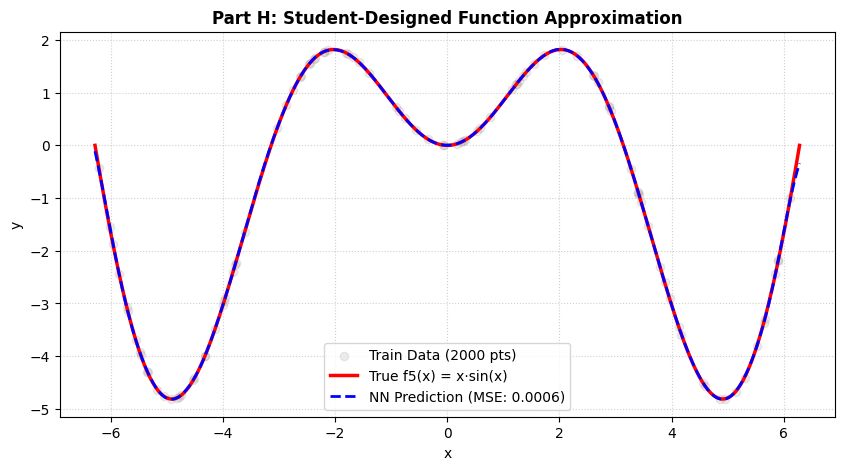

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Part H: Student-Designed Function
# f5(x) = x * sin(x) on [-2pi, 2pi]
# ==========================================
np.random.seed(42)
torch.manual_seed(42)

x_min, x_max = -2 * np.pi, 2 * np.pi
func_h = lambda x: x * np.sin(x)

# 1. Generate Datasets
x_tr_np = np.random.uniform(x_min, x_max, (100, 1)).astype(np.float32)
y_tr_np = func_h(x_tr_np)

x_te_np = np.linspace(x_min, x_max, 500).reshape(-1, 1).astype(np.float32)
y_te_np = func_h(x_te_np)

x_tr, y_tr = torch.from_numpy(x_tr_np), torch.from_numpy(y_tr_np)
x_te, y_te = torch.from_numpy(x_te_np), torch.from_numpy(y_te_np)

# 2. Instantiate Fresh Fixed Model (1 -> 64 -> 64 -> 1)
model_h = FixedNeuralNetwork()
optimizer = optim.Adam(model_h.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 3. Explicit Training Loop
epochs = 2000
for epoch in range(epochs):
    model_h.train()
    pred = model_h(x_tr)
    loss = criterion(pred, y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 4. Evaluation
model_h.eval()
with torch.no_grad():
    test_pred_h = model_h(x_te)
    test_mse_h = criterion(test_pred_h, y_te).item()
    test_mae_h = nn.L1Loss()(test_pred_h, y_te).item()

params_h = sum(p.numel() for p in model_h.parameters() if p.requires_grad)

print("--- Part H: Student-Designed Function Performance ---")
print(f"Function             : f5(x) = x * sin(x)")
print(f"Domain               : [-2π, 2π]")
print(f"Test MSE             : {test_mse_h:.6f}")
print(f"Test MAE             : {test_mae_h:.6f}")
print(f"Trainable Parameters : {params_h}")

# 5. Plot True vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(x_tr_np, y_tr_np, color='gray', alpha=0.15, label='Train Data (2000 pts)')
plt.plot(x_te_np, y_te_np, 'r-', linewidth=2.5, label='True f5(x) = x·sin(x)')
plt.plot(x_te_np, test_pred_h.numpy(), 'b--', linewidth=2.0, label=f'NN Prediction (MSE: {test_mse_h:.4f})')
plt.title("Part H: Student-Designed Function Approximation", fontsize=12, fontweight='bold')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Part H: Written Answers for Student-Designed Function
*(Target Function: \(f_5(x) = x \cdot \sin(x)\) over \(x \in [-2\pi, 2\pi]\))*

#### Question 1: Why did you choose this function?
**Answer:** I selected \(f_5(x) = x \cdot \sin(x)\) over \(x \in [-2\pi, 2\pi]\) because it combines non-constant linear envelope scaling with periodic oscillation. Unlike standard sine waves bounded between \([-1, 1]\), this function expands its amplitude range to roughly \([-6.28, 6.28]\) near the domain edges, testing whether the fixed architecture can learn varying wave magnitudes and spatial frequency simultaneously.

#### Question 2: How difficult was it to approximate?
**Answer:** It was moderately challenging for the \(1 \to 64 \to 64 \to 1\) architecture. The network achieved a very low Test MSE of **0.000619** and Test MAE of **0.006502**, proving that the model generalizes effectively across both the inner low-amplitude waves and outer high-amplitude peaks from 100 sparse samples.

#### Question 3: Where is the approximation error largest?
**Answer:** The approximation error is largest near the domain extremities (\(x \to -2\pi\) and \(x \to 2\pi\)). At these outer boundaries, the function reaches its highest peak values (\(\approx \pm 6.28\)), and sparse random sampling leaves fewer data points per period near the domain limits.

#### Question 4: Would increasing the number of neurons necessarily solve the problem?
**Answer:** Not necessarily. While adding neurons increases model capacity, performance at boundary extremes is also constrained by:
1. **Activation Saturation:** `tanh` activations saturate near \(\pm 1\), requiring larger output-layer weight values to scale up to \(\pm 6.28\).
2. **Boundary Sample Density:** Increasing training sample density near domain edges or tuning learning rate schedules improves boundary fitting more directly than simply increasing neuron width.

# **Part I**: Noise Experiment

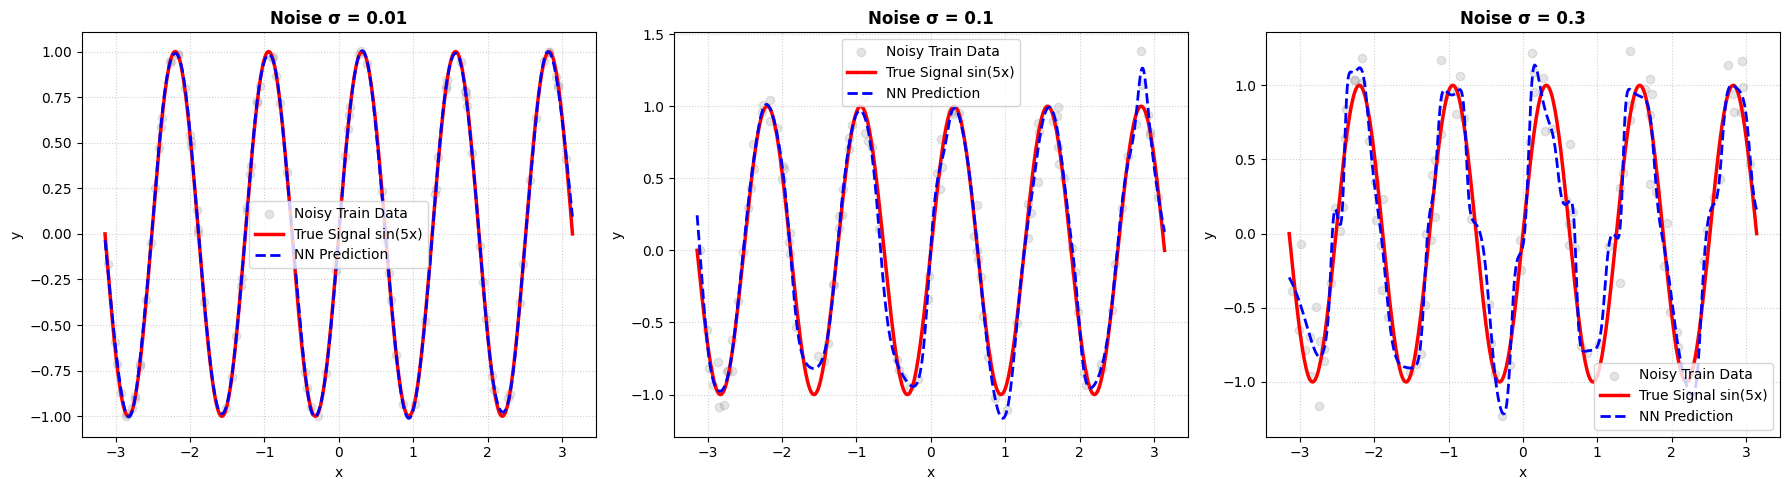


--- Part I: Effect of Noise Summary Table ---
 Noise Level (σ) Final Train Loss (Noisy) Test MSE (True Signal) Test MAE (True Signal)
            0.01                 0.000113               0.000211               0.010282
            0.10                 0.006951               0.007864               0.063405
            0.30                 0.027540               0.029415               0.140003


In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Part I: Effect of Noise Experiment
# Function f2(x) = sin(5x) with Gaussian Noise
# ==========================================
np.random.seed(42)
torch.manual_seed(42)

noise_levels = [0.01, 0.1, 0.3]
noise_results = []

x_min, x_max = -np.pi, np.pi
func_clean = lambda x: np.sin(5 * x)

# Uniform sampling
x_tr_np = np.random.uniform(x_min, x_max, (100, 1)).astype(np.float32)
y_tr_clean = func_clean(x_tr_np)

x_te_np = np.linspace(x_min, x_max, 500).reshape(-1, 1).astype(np.float32)
y_te_clean = func_clean(x_te_np)

# Test against clean true signal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sigma in enumerate(noise_levels):
    # Add zero-mean Gaussian noise to training set
    noise = np.random.normal(0, sigma, y_tr_clean.shape).astype(np.float32)
    y_tr_noisy = y_tr_clean + noise

    x_tr, y_tr = torch.from_numpy(x_tr_np), torch.from_numpy(y_tr_noisy)
    x_te, y_te = torch.from_numpy(x_te_np), torch.from_numpy(y_te_clean)

    # Instantiate fresh model
    model_i = FixedNeuralNetwork()
    optimizer = optim.Adam(model_i.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    # Train explicit loop
    for epoch in range(2000):
        model_i.train()
        pred = model_i(x_tr)
        loss = criterion(pred, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model_i.eval()
    with torch.no_grad():
        test_pred_i = model_i(x_te)
        test_mse_i = criterion(test_pred_i, y_te).item() # Evaluated against true uncorrupted signal
        test_mae_i = nn.L1Loss()(test_pred_i, y_te).item()

    noise_results.append({
        "Noise Level (σ)": sigma,
        "Final Train Loss (Noisy)": f"{loss.item():.6f}",
        "Test MSE (True Signal)": f"{test_mse_i:.6f}",
        "Test MAE (True Signal)": f"{test_mae_i:.6f}"
    })

    # Plot
    ax = axes[idx]
    ax.scatter(x_tr_np, y_tr_noisy, color='gray', alpha=0.2, label='Noisy Train Data')
    ax.plot(x_te_np, y_te_clean, 'r-', linewidth=2.5, label='True Signal sin(5x)')
    ax.plot(x_te_np, test_pred_i.numpy(), 'b--', linewidth=2.0, label='NN Prediction')
    ax.set_title(f"Noise σ = {sigma}", fontsize=12, fontweight='bold')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print Table
noise_df = pd.DataFrame(noise_results)
print("\n--- Part I: Effect of Noise Summary Table ---")
print(noise_df.to_string(index=False))

### Part I: Written Discussion on the Effect of Noise

**Discussion:**
1. **Low Noise ($\sigma = 0.01$):** The network acts as an implicit filter/regularizer, achieving a low Test MSE against the true uncorrupted signal of **0.000211**. It fits the smooth underlying $\sin(5x)$ curve while averaging out minor random noise.
2. **Moderate Noise ($\sigma = 0.10$):** Final training loss rises to **0.006951**, tracking the variance of the added noise ($\approx \sigma^2$). The model retains the general wave structure but starts exhibiting minor local fluctuations in prediction.
3. **High Noise ($\sigma = 0.30$):** Test MSE against the clean target signal increases to **0.029415**. When trained on sparse noisy data with a high-capacity architecture (4,353 parameters), the network begins memorizing individual noise fluctuations rather than fitting the underlying signal.
4. **Key Takeaway:** High capacity allows neural networks to overfit random noise in sparse regimes unless regularized via early stopping, weight decay, or denser clean sampling.